In [113]:
import os
from pathlib import Path
from datetime import datetime
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F


def _find_cnn_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "data" / "BTCUSDT-1h-data.csv").is_file():
            return p
        cand = p / "CNN" / "data" / "BTCUSDT-1h-data.csv"
        if cand.is_file():
            return (p / "CNN").resolve()
    return here


CNN_ROOT = _find_cnn_root()
ARTIFACTS = CNN_ROOT / "artifacts"
DATA_CSV = CNN_ROOT / "data" / "BTCUSDT-1h-data.csv"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("ensemble_models", exist_ok=True)

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

seed = 0
set_all_seeds(seed)



In [114]:
df = pd.read_csv(DATA_CSV)
print(df)


       Unnamed: 0                  timestamp      open_time       open  \
0               0  2017-08-17 04:00:00+00:00  1502942400000    4261.48   
1               1  2017-08-17 05:00:00+00:00  1502946000000    4308.83   
2               2  2017-08-17 06:00:00+00:00  1502949600000    4330.29   
3               3  2017-08-17 07:00:00+00:00  1502953200000    4316.62   
4               4  2017-08-17 08:00:00+00:00  1502956800000    4333.32   
...           ...                        ...            ...        ...   
69079        8755  2025-07-09 19:00:00+00:00  1752087600000  109536.50   
69080        8756  2025-07-09 20:00:00+00:00  1752091200000  111749.99   
69081        8757  2025-07-09 21:00:00+00:00  1752094800000  110714.97   
69082        8758  2025-07-09 22:00:00+00:00  1752098400000  110818.36   
69083        8759  2025-07-09 23:00:00+00:00  1752102000000  111382.17   

            high        low      close       volume     close_time  \
0        4313.62    4261.32    4308.83   

**Check missing values**

In [115]:
print(df.isnull())
print(f"Counts how many missing values there are in each column: {df.isnull().sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

       Unnamed: 0  timestamp  open_time   open   high    low  close  volume  \
0           False      False      False  False  False  False  False   False   
1           False      False      False  False  False  False  False   False   
2           False      False      False  False  False  False  False   False   
3           False      False      False  False  False  False  False   False   
4           False      False      False  False  False  False  False   False   
...           ...        ...        ...    ...    ...    ...    ...     ...   
69079       False      False      False  False  False  False  False   False   
69080       False      False      False  False  False  False  False   False   
69081       False      False      False  False  False  False  False   False   
69082       False      False      False  False  False  False  False   False   
69083       False      False      False  False  False  False  False   False   

       close_time  quote_av  trades  tb_base_av  tb

**Split data**

In [116]:
import json

with open(ARTIFACTS / "split_info.json", "r", encoding="utf-8") as f:
    sp = json.load(f)
train_end = int(sp["train_end"])
val_end = int(sp["val_end"])
total_rows = int(sp.get("total_rows", len(df)))

with open(ARTIFACTS / "scalers.pkl", "rb") as f:
    train_scalers = pickle.load(f)

df_sel = df.iloc[train_end:val_end].copy()
df_hold = df.iloc[val_end:total_rows].copy()

print(f"Selection (test) slice [{train_end}:{val_end}] len={len(df_sel)}")
print(f"Holdout (backtest) slice [{val_end}:{total_rows}] len={len(df_hold)}")


Selection (test) slice [54000:63000] len=9000
Holdout (backtest) slice [63000:69084] len=6084


**Building Meaningful Features**

In [117]:
def build_features(opens, highs, lows, closes, volumes, train_scalers=None):

    # Build features
    feature1 = (closes - opens) / opens
    feature2 = (highs - opens) / opens
    feature3 = (highs - closes) / closes
    feature4 = (lows - opens) / opens
    feature5 = (lows - closes) / closes
    feature6 = (highs - lows) / opens
    feature7 = (highs - lows) / closes
    feature8 = volumes

    # Stack features
    features = [
        feature1,
        feature2,
        feature3,
        feature4,
        feature5,
        feature6,
        feature7,
        feature8,
    ]
    num_features = len(features)
    scaled_fts = []

    if train_scalers is None:
        train_scalers = [MaxAbsScaler() for _ in range(num_features)]
        is_train = True
    else:
        is_train = False

    for i in range(num_features):
        # Get train scaler
        scaler = train_scalers[i]
        if is_train:
            # Scaler -> Fit -> Train dataset
            scaled_ft = scaler.fit_transform(features[i].reshape(-1, 1))
            # Save the train scaler in a list
        elif not is_train:
            # Scaler -> NOT Fit -> Test dataset
            scaled_ft = scaler.transform(features[i].reshape(-1, 1))

        # Update list of SCALED features
        scaled_fts.append(scaled_ft.flatten())

    # Stack features
    scaled_features = np.stack(scaled_fts, axis=-1)

    # Get num. features
    num_features = scaled_features.shape[-1]
    return scaled_features, num_features, train_scalers

**Preprocess data**

In [118]:
def preprocess_data(seq_len, df, train_scalers=None):
    m = len(df)

    opens = np.array(df['open'].values)
    highs = np.array(df['high'].values)
    lows = np.array(df['low'].values)
    closes = np.array(df['close'].values)
    volumes = np.array(df['volume'].values)

    # Build features
    features, num_features, train_scalers = build_features(opens, highs, lows, closes, volumes, train_scalers)

    # Calculate number of samples
    num_samples = m - seq_len

    # Create storage for inputs & targets
    X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
    Y = np.zeros([num_samples, num_features], dtype=np.float32)

    # Create samples (X, Y)
    for i in range(num_samples):
        X[i] = features[i : i+seq_len]
        Y[i] = features[i+seq_len : i+seq_len+1]

    # Fix alignment
    opens = np.array(opens[seq_len:])
    highs = np.array(highs[seq_len:])
    lows = np.array(lows[seq_len:])
    closes = np.array(closes[seq_len:])

    return X, Y, num_features, opens, highs, lows, closes, train_scalers

In [119]:
# Sequence Length
seq_len = 48

# Transform only — scalers loaded from artifacts (no fit on post-train rows)
X_sel, Y_sel, num_features, sel_opens, sel_highs, sel_lows, sel_closes, _ = preprocess_data(
    seq_len, df_sel, train_scalers
)
X_hold, Y_hold, num_features, ho_opens, ho_highs, ho_lows, ho_closes, _ = preprocess_data(
    seq_len, df_hold, train_scalers
)



In [120]:
m_sel = X_sel.shape[0]
m_hold = X_hold.shape[0]
print(f"m_sel: {m_sel}")
print(f"m_hold: {m_hold}")
print(f"X_sel shape: {X_sel.shape}")
print(f"X_hold shape: {X_hold.shape}")
print(f"num_features: {num_features}")


m_sel: 8952
m_hold: 6036
X_sel shape: (8952, 48, 8)
X_hold shape: (6036, 48, 8)
num_features: 8


**Transform data to Torch Tensor**

In [121]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("my device: ", device)

X_sel_t = torch.from_numpy(X_sel.astype(np.float32)).to(device, dtype=torch.float32)
X_hold_t = torch.from_numpy(X_hold.astype(np.float32)).to(device, dtype=torch.float32)



my device:  cuda:0


**Build model**

In [122]:
class Model_1(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1 block #1
        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=32,
            kernel_size=3,
            padding=1,
            stride=1,
        )
        self.act1 = nn.GELU()

        # Conv1 block #2
        self.conv2 = nn.Conv1d(
            in_channels=32, 
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        self.act2 = nn.GELU()

        # Output layer
        self.fc_out = nn.Linear(64, num_features)

    def forward(self, x):
        x = x.permute(0, 2, 1) # (batch, num_features, seq_len)

        # Conv block #1
        x = self.conv1(x)
        x = self.act1(x)

        # Conv block #2
        x = self.conv2(x)
        x = self.act2(x)

        x = x.permute(0, 2, 1) # (batch, seq_len, num_features)
        x = x[:, -1, :] # get last hidden

        # Output layer
        x = self.fc_out(x)
        return x

In [123]:
class Model_2(nn.Module):
    def __init__(self):
        super().__init__()

        # LSTM
        self.lstm = nn.LSTM(input_size=num_features,
                            hidden_size=64,
                            num_layers=1,
                            batch_first=True)

        # Output layer
        self.fc_out = nn.Linear(64, num_features)

    def forward(self, x):
        # LSTM
        x, (h_n, c_n) = self.lstm(x)
        x = x[:, -1, :] 

        # Output layer
        x = self.fc_out(x)
        return x

In [124]:
class Model_3(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1D
        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=64,
            kernel_size=3,
            padding=1,
            stride=1,
        )
        self.act1 = nn.GELU()

        # LSTM
        self.lstm = nn.LSTM(64, 32, batch_first=True)

        # Output layer
        self.fc_out = nn.Linear(32, num_features)

    def forward(self, x):
        # Conv1D
        x = x.permute(0, 2, 1) # (batch, num_features, seq_len)
        x = self.conv1(x)
        x = self.act1(x)
        x = x.permute(0, 2, 1) # (batch, seq_len, num_features)

        # LSTM
        x, (h_n, c_n) = self.lstm(x)
        x = x[:, -1, :]

        # Output layer
        x = self.fc_out(x)
        return x



In [125]:
import json

manifest_path = ARTIFACTS / "manifest.json"
with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

ARCH_MAP = {"conv1d": Model_1, "lstm": Model_2, "hybrid": Model_3}

MODELS_INFOS = []
for arch_name in ["conv1d", "lstm", "hybrid"]:
    if arch_name not in manifest:
        continue
    rel_paths = manifest[arch_name]
    abs_paths = [str(CNN_ROOT / Path(*rp.split("/"))) for rp in rel_paths]
    MODELS_INFOS.append({"paths": abs_paths, "architecture": ARCH_MAP[arch_name]})

if not MODELS_INFOS:
    raise FileNotFoundError(
        "No entries in manifest.json — run training notebooks (artifact cells) first."
    )


def ensemble_raw_signals(X_t: torch.Tensor, m_len: int):
    out = []
    for model_info in MODELS_INFOS:
        architecture = model_info["architecture"]
        for model_path in model_info["paths"]:
            model = architecture().to(device)
            model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))
            model.eval()
            Y_pred = torch.zeros([m_len, num_features], device=device, dtype=torch.float32)
            with torch.no_grad():
                chunks = 16
                while True:
                    try:
                        mchunk = max(1, m_len // chunks)
                        for j in range(chunks + 1):
                            start = mchunk * j
                            if start >= m_len:
                                break
                            end = min(mchunk * (j + 1), m_len)
                            Y_pred[start:end] = model(X_t[start:end])
                        break
                    except Exception as err:
                        print(f"Chunks ({chunks}) err: {err}")
                        chunks += 2
            out.append(Y_pred.detach().cpu().numpy()[:, 0].copy())
    return out


def trading_backtest(all_raw_signals, opens, highs, lows, closes, phase_label: str):
    TAKER_FEE = 0.00055
    pos_size = 1000.0
    SL_POINTS = 50.0
    TP_POINTS = 700.0
    THRESHOLD = 0.0008

    cash = 1000.0
    position = 0
    entry_price = None

    equities = []
    fee_log = []
    actions_log = []

    total_fees = 0.0
    entries = 0
    completed_trades = 0
    sl_hits = 0
    tp_hits = 0
    num_longs = 0
    num_shorts = 0
    trade_pnls = []

    def taker_fee():
        return pos_size * TAKER_FEE

    def realize_to(price):
        nonlocal cash, entry_price, position, completed_trades, total_fees, trade_pnls
        if position == 0 or entry_price is None:
            return
        pct = (price - entry_price) / entry_price
        pnl = pos_size * (pct if position == 1 else -pct)
        fee = taker_fee()
        cash += pnl - fee
        total_fees += fee
        trade_pnls.append(pnl - fee)
        entry_price = None
        position = 0
        completed_trades += 1

    def mark_to_market(close_price):
        if position == 0 or entry_price is None:
            return cash
        pct = (close_price - entry_price) / entry_price
        return cash + pos_size * (pct if position == 1 else -pct)

    n = len(opens) - 1
    for i in range(n):
        curr_open = opens[i]
        curr_high = highs[i]
        curr_low = lows[i]
        curr_close = closes[i]
        bar_fee = 0.0

        raw_values = [arr[i] for arr in all_raw_signals]
        mean_signal = np.mean(raw_values)

        if mean_signal > THRESHOLD:
            desired = 1
        elif mean_signal < -THRESHOLD:
            desired = -1
        else:
            desired = 0

        if position != 0 and entry_price is not None:
            sl_price = entry_price - SL_POINTS if position == 1 else entry_price + SL_POINTS
            tp_price = entry_price + TP_POINTS if position == 1 else entry_price - TP_POINTS

            if (position == 1 and curr_high >= tp_price) or (position == -1 and curr_low <= tp_price):
                realize_to(tp_price)
                tp_hits += 1

            elif (position == 1 and curr_low <= sl_price) or (position == -1 and curr_high >= sl_price):
                realize_to(sl_price)
                sl_hits += 1

        if position == 0 and desired != 0:
            fee = taker_fee()
            cash -= fee
            bar_fee += fee
            total_fees += fee
            entry_price = curr_open
            position = desired
            entries += 1
            num_longs += desired == 1
            num_shorts += desired == -1

        equity = mark_to_market(curr_close)
        equities.append(equity)
        fee_log.append(bar_fee)
        actions_log.append(position)

    if position != 0:
        realize_to(closes[len(equities) - 1])

    win_trades = sum(1 for p in trade_pnls if p > 0)
    win_rate = win_trades / len(trade_pnls) * 100 if trade_pnls else 0
    avg_pnl = np.mean(trade_pnls) if trade_pnls else 0

    print(f"===== {phase_label} =====")
    print(f"Entries: {entries} | Completed: {completed_trades}")
    print(f"Longs: {num_longs} | Shorts: {num_shorts}")
    print(f"SL hits: {sl_hits} | TP hits: {tp_hits}")
    print(f"Win rate: {win_rate:.1f}% | Avg PnL/trade: ${avg_pnl:.2f}")
    print(f"Total fees: ${total_fees:.2f}")
    print(f"Final equity: ${equities[-1]:.2f}")
    return equities


raw_sel = ensemble_raw_signals(X_sel_t, m_sel)
equities_selection = trading_backtest(raw_sel, sel_opens, sel_highs, sel_lows, sel_closes, "selection [train_end:val_end]")

raw_hold = ensemble_raw_signals(X_hold_t, m_hold)
equities_holdout = trading_backtest(raw_hold, ho_opens, ho_highs, ho_lows, ho_closes, "holdout [val_end:end]")



C:\Users\jtoma\AppData\Local\Temp\ipykernel_10928\735265765.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=to

===== selection [train_end:val_end] =====
Entries: 3828 | Completed: 3828
Longs: 3336 | Shorts: 492
SL hits: 2976 | TP hits: 851
Win rate: 22.3% | Avg PnL/trade: $1.47
Total fees: $4210.80
Final equity: $4520.57
===== holdout [val_end:end] =====
Entries: 3357 | Completed: 3357
Longs: 3016 | Shorts: 341
SL hits: 2363 | TP hits: 993
Win rate: 29.6% | Avg PnL/trade: $1.28
Total fees: $3692.70
Final equity: $3460.94


Result: Equity: 3461, Sharpe Ratio 0.0697, Drawdown 5.18%


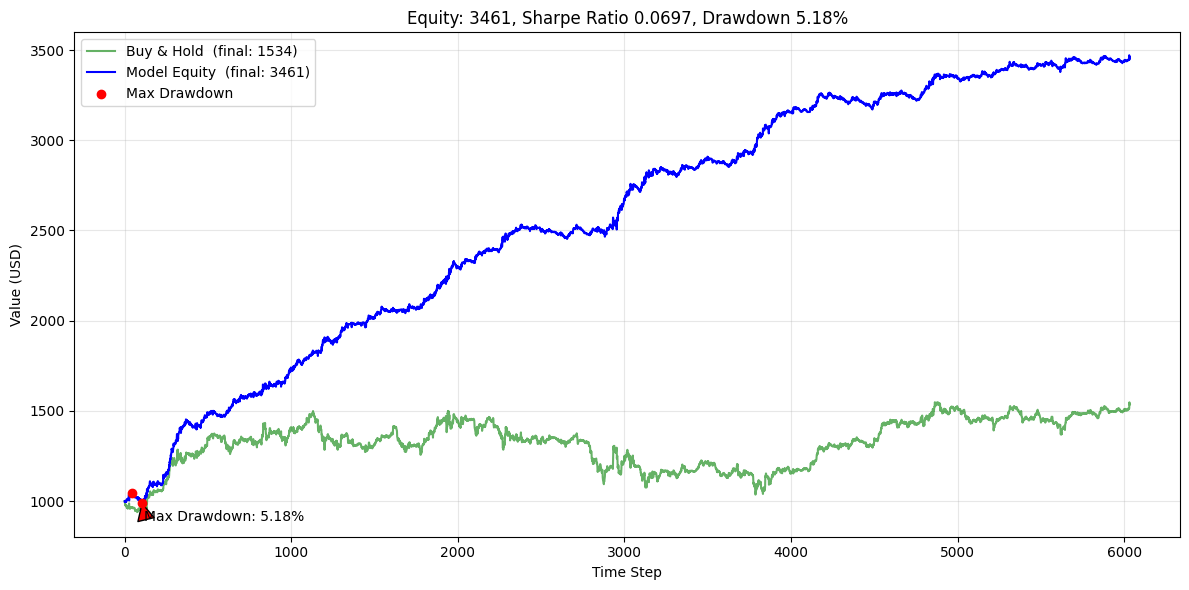

In [126]:
# Calculate max drawdown
def calculate_max_drawdown(equities):
    # Convert to numpy array for vectorized operations
    equity = np.array(equities)

    # Calculate cumulative maximum (peak equity)
    peak = np.maximum.accumulate(equity)

    # Drawdown: (Peak - Current) / Peak
    drawdown = (peak - equity) / peak

    # Index of maximum drawdown
    max_dd_idx = np.argmax(drawdown)

    # Find the peak before the maximum drawdown
    peak_idx = np.argmax(equity[:max_dd_idx + 1])

    return {
        "max_drawdown": drawdown[max_dd_idx],
        "peak_index": peak_idx,
        "trough_index": max_dd_idx,
        "peak_value": equity[peak_idx],
        "trough_value": equity[max_dd_idx]
    }

# Calculate Sharpe Ratio
def calculate_sharpe_ratio(equities):
    # Step 1: Compute 15-minute returns
    returns = []
    for i in range(1, len(equities)):
        ret = (equities[i] - equities[i-1]) / equities[i-1]
        returns.append(ret)

    # Step 2: Mean return
    mean_return = np.mean(returns)

    # Step 3: Standard deviation
    std_dev = np.std(returns, ddof=1)

    # Step 4: Sharpe Ratio (assuming risk-free rate = 0)
    sharpe_ratio = mean_return / std_dev

    sharpe_ratio = round(sharpe_ratio, 4)
    return sharpe_ratio


def plot_equity(backtest_opens, equities, result, sharpe_ratio):
    chart_title = f"Equity: {equities[-1]:.0f}, Sharpe Ratio {sharpe_ratio:.4f}, Drawdown {result['max_drawdown']:.2%}"
    print(f"Result: {chart_title}")

    # Buy & hold: investe pos_size no primeiro close e acompanha ate ao fim
    pos_size = 1000.0
    prices = np.array(backtest_opens[:len(equities)])
    buy_and_hold = pos_size * (prices / prices[0])

    fig, ax = plt.subplots(figsize=(12, 6))

    # Buy & hold
    ax.plot(
        buy_and_hold,
        color="green",
        alpha=0.6,
        lw=1.5,
        label=f"Buy & Hold  (final: {buy_and_hold[-1]:.0f})"
    )

    # Equity do modelo
    ax.plot(
        equities,
        color="blue",
        lw=1.5,
        label=f"Model Equity  (final: {equities[-1]:.0f})"
    )

    # Max drawdown
    ax.scatter(
        [result["peak_index"], result["trough_index"]],
        [result["peak_value"], result["trough_value"]],
        color="red", zorder=5, label="Max Drawdown"
    )
    ax.annotate(
        f"Max Drawdown: {result['max_drawdown']:.2%}",
        xy=(result["trough_index"], result["trough_value"]),
        xytext=(result["trough_index"] + 10, result["trough_value"] * 0.9),
        arrowprops=dict(facecolor="red", shrink=0.05),
    )

    ax.set_title(chart_title)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value (USD)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # plt.savefig(chart_title.replace('%', '')+'.png', dpi=300)
# Curva do holdout (fora da amostra); tens também `equities_selection` se quiseres comparar
equities = equities_holdout
backtest_opens = ho_opens

# Calculate sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(equities)

# Calculate Max DD
result = calculate_max_drawdown(equities)

# Generate the plot
plot_equity(backtest_opens, equities, result, sharpe_ratio)